# Car Image Generation using Diffusion Models

In [1]:
import os
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import kagglehub

print("Downloading The Car Connection Picture Dataset...")
raw_path = kagglehub.dataset_download("prondeau/the-car-connection-picture-dataset")
print("Path to dataset files:", raw_path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 64  # Increased image size for better quality
BATCH_SIZE = 128

class FlatImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_files = [f for f in os.listdir(root_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.image_files[idx])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, 0

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),

    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

dataset = FlatImageDataset(root_dir=raw_path, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

print(f"Using device: {device}")
print(f"Dataset size: {len(dataset)} car images loaded successfully!")

100%|██████████| 682M/682M [00:09<00:00, 72.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/prondeau/the-car-connection-picture-dataset/versions/1
Using device: cuda
Dataset size: 64467 car images loaded successfully!


## Data Loading and Preprocessing

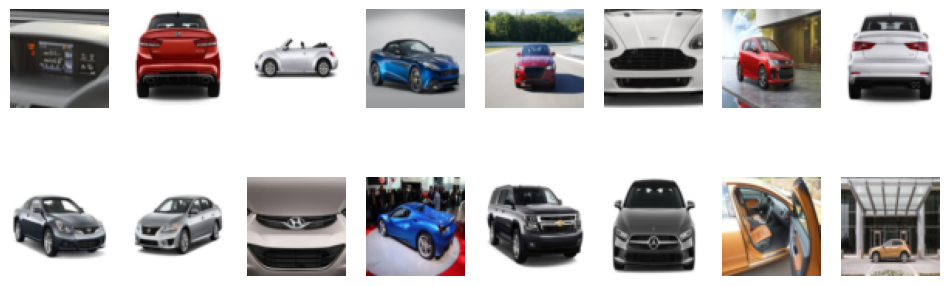

In [2]:
images, _ = next(iter(dataloader))
grid_img = images[:16]
grid_img = grid_img / 2 + 0.5
grid_img = grid_img.numpy()
grid_img = np.transpose(grid_img, (0, 2, 3, 1))

fig, axes = plt.subplots(2, 8, figsize=(12, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(grid_img[i])
    ax.axis('off')
plt.show()

## Visualize Sample Images from Dataset

In [3]:
TIMESTEPS = 300
beta_start = 0.0001
beta_end = 0.02

betas = torch.linspace(beta_start, beta_end, TIMESTEPS, device=device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

def forward_diffusion(x_0, t):
    noise = torch.randn_like(x_0)
    sqrt_alphas_cumprod_t = torch.sqrt(alphas_cumprod[t]).view(-1, 1, 1, 1)
    sqrt_one_minus_alphas_cumprod_t = torch.sqrt(1.0 - alphas_cumprod[t]).view(-1, 1, 1, 1)
    x_t = sqrt_alphas_cumprod_t * x_0 + sqrt_one_minus_alphas_cumprod_t * noise
    return x_t, noise

## Diffusion Process Parameters and Forward Diffusion Function

In [4]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

## Sinusoidal Position Embeddings for Time Encoding

In [5]:
class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bnorm1 = nn.BatchNorm2d(out_ch)
        self.bnorm2 = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU()

    def forward(self, x, t):
        h = self.relu(self.bnorm1(self.conv1(x)))
        time_emb = self.relu(self.time_mlp(t))
        time_emb = time_emb.view(-1, time_emb.shape[1], 1, 1)
        h = h + time_emb
        h = self.relu(self.bnorm2(self.conv2(h)))
        return h

class SimpleUNet(nn.Module):
    def __init__(self):
        super().__init__()
        image_channels = 3
        down_channels = (128, 256, 512)
        out_dim = 3
        time_emb_dim = 32

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU()
        )

        self.downs = nn.ModuleList([])
        in_c = image_channels
        for out_c in down_channels:
            self.downs.append(Block(in_c, out_c, time_emb_dim))
            in_c = out_c

        self.mid_block = Block(512, 512, time_emb_dim)

        self.ups = nn.ModuleList([])
        self.ups.append(Block(512 + 256, 256, time_emb_dim))
        self.ups.append(Block(256 + 128, 128, time_emb_dim))

        self.down_sample = nn.MaxPool2d(2)
        self.up_sample = nn.ModuleList([
            nn.ConvTranspose2d(512, 512, 2, 2),
            nn.ConvTranspose2d(256, 256, 2, 2)
        ])

        self.final_conv = nn.Conv2d(128, out_dim, 1)

    def forward(self, x, time):
        t = self.time_mlp(time)
        residuals = []

        for i, down in enumerate(self.downs):
            x = down(x, t)
            if i < len(self.downs) - 1:
                residuals.append(x)
                x = self.down_sample(x)

        x = self.mid_block(x, t)

        for i, up in enumerate(self.ups):
            x = self.up_sample[i](x)
            res = residuals.pop()
            x = torch.cat((x, res), dim=1)
            x = up(x, t)

        return self.final_conv(x)

model = SimpleUNet().to(device)
print("Upgraded U-Net initialized for sharp car generation!")

Upgraded U-Net initialized for sharp car generation!


## U-Net Model Architecture

# **Training**

In [8]:
import torch.optim as optim
import torch.cuda.amp as amp

EPOCHS = 15
optimizer = optim.AdamW(model.parameters(), lr=8e-4)
loss_fn = nn.MSELoss()
scaler = amp.GradScaler()

print("Starting Training on T4 GPU with Car Connection DatasetQ=eW...")
for epoch in range(EPOCHS):
    epoch_loss = 0.0
    for step, (batch_images, _) in enumerate(dataloader):
        batch_images = batch_images.to(device)

        t = torch.randint(0, TIMESTEPS, (BATCH_SIZE,), device=device).long()

        # Use autocast for mixed precision training
        with amp.autocast():
            x_noisy, pure_noise = forward_diffusion(batch_images, t)
            predicted_noise = model(x_noisy, t)
            loss = loss_fn(predicted_noise, pure_noise)

        optimizer.zero_grad()
        scaler.scale(loss).backward() # Scale loss before backward pass
        scaler.step(optimizer) # Update optimizer with scaled gradients
        scaler.update() # Update the scaler for the next iteration

        epoch_loss += loss.item()

    print(f"Epoch {epoch+1:02d}/{EPOCHS:02d} | Average MSE Loss: {epoch_loss / len(dataloader):.5f}")

print("Training Complete!")

/tmp/ipykernel_530/1777624048.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler() # Initialize GradScaler for mixed precision
/tmp/ipykernel_530/1777624048.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


Starting Training on T4 GPU with Car Connection DatasetQ=eW...
Epoch 01/15 | Average MSE Loss: 0.06264
Epoch 02/15 | Average MSE Loss: 0.05009
Epoch 03/15 | Average MSE Loss: 0.04514
Epoch 04/15 | Average MSE Loss: 0.04239
Epoch 05/15 | Average MSE Loss: 0.04081
Epoch 06/15 | Average MSE Loss: 0.03922
Epoch 07/15 | Average MSE Loss: 0.03811
Epoch 08/15 | Average MSE Loss: 0.03715
Epoch 09/15 | Average MSE Loss: 0.03672
Epoch 10/15 | Average MSE Loss: 0.03615
Epoch 11/15 | Average MSE Loss: 0.03528
Epoch 12/15 | Average MSE Loss: 0.03502
Epoch 13/15 | Average MSE Loss: 0.03505
Epoch 14/15 | Average MSE Loss: 0.03432


/tmp/ipykernel_530/1777624048.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/tmp/ipykernel_530/1777624048.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/tmp/ipykernel_530/1777624048.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/tmp/ipykernel_530/1777624048.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/tmp/ipykernel_530/1777624048.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/tmp/ipykernel_530/1777624048.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)

Epoch 15/15 | Average MSE Loss: 0.03427
Training Complete!


## Model Training

## Generate and Visualize Sample Images

Let's generate some new images from our trained diffusion model to see how well it's performing.

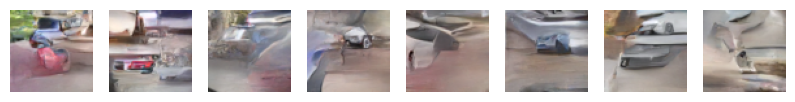

In [13]:
@torch.no_grad()
def sample_new_images(num_samples=4):
    model.eval()
    x = torch.randn(num_samples, 3, IMG_SIZE, IMG_SIZE, device=device)

    for t_step in reversed(range(TIMESTEPS)):
        t_tensor = torch.full((num_samples,), t_step, device=device, dtype=torch.long)

        predicted_noise = model(x, t_tensor)

        beta = betas[t_step]
        alpha = alphas[t_step]
        alpha_cumprod = alphas_cumprod[t_step]

        if t_step > 0:
            noise = torch.randn_like(x)
        else:
            noise = 0

        mean = (1 / torch.sqrt(alpha)) * (x - ((beta / torch.sqrt(1 - alpha_cumprod)) * predicted_noise))
        std_dev = torch.sqrt(beta)

        x = mean + std_dev * noise

    model.train()
    x = (x / 2 + 0.5).clamp(0, 1).cpu().numpy()
    x = np.transpose(x, (0, 2, 3, 1))

    fig, axes = plt.subplots(1, num_samples, figsize=(10, 3))
    for i, ax in enumerate(axes):
        ax.imshow(x[i])
        ax.axis('off')
    plt.show()

sample_new_images(num_samples=8)

## Generate and Visualize Sample Images from Trained Model